# Advanced Analytics for Bluestock Mutual Funds

This notebook extends the cleaned mutual fund dataset into risk analytics, investor behavior analysis, sector concentration, and a simple fund recommender.

Generated deliverables:
- `var_cvar_report.csv`
- `rolling_sharpe_chart.png`
- `recommender.py`


## 1. Load the processed datasets

We rely on the curated files under `data/processed` so the calculations match the cleaned pipeline output.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / 'data' / 'processed'

fund = pd.read_csv(DATA_DIR / '01_fund_master.csv')
nav = pd.read_csv(DATA_DIR / '02_nav_history.csv', parse_dates=['date'])
perf = pd.read_csv(DATA_DIR / '07_scheme_performance.csv')
trx = pd.read_csv(DATA_DIR / '08_investor_transactions.csv', parse_dates=['transaction_date'])
hold = pd.read_csv(DATA_DIR / '09_portfolio_holdings.csv')

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

print('fund rows:', len(fund))
print('nav rows:', len(nav))
print('performance rows:', len(perf))
print('transactions rows:', len(trx))
print('holdings rows:', len(hold))


fund rows: 40
nav rows: 64320
performance rows: 40
transactions rows: 32778
holdings rows: 322


## 2. Historical VaR and CVaR

- VaR (95%) is the 5th percentile of the daily return distribution.
- CVaR (95%) is the average of returns at or below that VaR threshold.

The report is saved as `var_cvar_report.csv`.


In [2]:
nav = nav.sort_values(['amfi_code', 'date']).copy()
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

var95 = nav.groupby('amfi_code')['daily_return'].quantile(0.05).rename('var_95')

def cvar_95(series):
    x = series.dropna()
    if x.empty:
        return np.nan
    threshold = x.quantile(0.05)
    tail = x[x <= threshold]
    return tail.mean() if not tail.empty else np.nan

cvar95 = nav.groupby('amfi_code')['daily_return'].apply(cvar_95).rename('cvar_95')
return_summary = nav.groupby('amfi_code').agg(
    return_obs=('daily_return', 'count'),
    mean_daily_return=('daily_return', 'mean'),
    daily_volatility=('daily_return', 'std')
).reset_index()

risk_report = (
    perf[['amfi_code', 'scheme_name', 'fund_house', 'category', 'risk_grade', 'sharpe_ratio', 'aum_crore', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'beta', 'std_dev_ann_pct', 'max_drawdown_pct']]
    .merge(fund[['amfi_code', 'sub_category']], on='amfi_code', how='left')
    .merge(var95.reset_index(), on='amfi_code', how='left')
    .merge(cvar95.reset_index(), on='amfi_code', how='left')
    .merge(return_summary, on='amfi_code', how='left')
)

risk_report['var_95_pct'] = risk_report['var_95'] * 100
risk_report['cvar_95_pct'] = risk_report['cvar_95'] * 100
risk_report['mean_daily_return_pct'] = risk_report['mean_daily_return'] * 100
risk_report['daily_volatility_pct'] = risk_report['daily_volatility'] * 100

risk_report = risk_report[[
    'amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category', 'risk_grade',
    'sharpe_ratio', 'aum_crore', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
    'beta', 'std_dev_ann_pct', 'max_drawdown_pct', 'mean_daily_return_pct',
    'daily_volatility_pct', 'var_95_pct', 'cvar_95_pct', 'return_obs'
]].sort_values('var_95_pct')

risk_report.head(10)


,amfi_code,scheme_name,fund_house,category,sub_category,risk_grade,sharpe_ratio,aum_crore,return_1yr_pct,return_3yr_pct,return_5yr_pct,beta,std_dev_ann_pct,max_drawdown_pct,mean_daily_return_pct,daily_volatility_pct,var_95_pct,cvar_95_pct,return_obs
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Small Cap,Very High,0.90,41613,24.93,22.38,23.80,0.97,25.0,-23.61,0.030348,1.374089,-2.391462,-3.028854,1607
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Small Cap,Very High,0.84,21545,21.97,20.98,22.62,1.00,25.0,-14.45,0.013039,1.335061,-2.328360,-2.969004,1607
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Small Cap,Very High,0.93,36061,20.59,23.14,21.82,1.04,25.0,-24.78,0.014394,1.328865,-2.315543,-3.016286,1607
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Small Cap,Very High,0.81,43630,21.30,20.15,21.88,1.03,25.0,-30.87,0.050558,1.344732,-2.280981,-2.993962,1607
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Small Cap,Very High,0.80,35124,20.20,20.08,20.61,0.98,25.0,-17.01,0.085383,1.324078,-2.152030,-2.857253,1607
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Small Cap,Very High,0.94,19259,24.56,23.39,20.67,0.89,25.0,-13.35,0.085872,1.340075,-2.150192,-2.844427,1607
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Mid Cap,High,0.80,28996,14.88,15.18,18.94,1.00,19.0,-32.38,0.073409,1.034655,-1.699654,-2.237453,1607
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Mid Cap,High,0.96,47469,17.12,18.23,17.75,1.00,19.0,-21.92,0.022301,0.953169,-1.694994,-2.125069,1607
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Mid Cap,High,0.87,23185,15.43,16.58,17.69,0.91,19.0,-13.67,0.077206,1.009740,-1.690163,-2.184984,1607
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,Mid Cap,High,0.82,41728,16.30,15.61,15.86,0.92,19.0,-13.43,0.007852,0.965853,-1.685705,-2.177063,1607


## 3. Rolling 90-day Sharpe ratio

We compute a 90-day rolling Sharpe ratio for 5 large-AUM funds and save the chart as `rolling_sharpe_chart.png`.


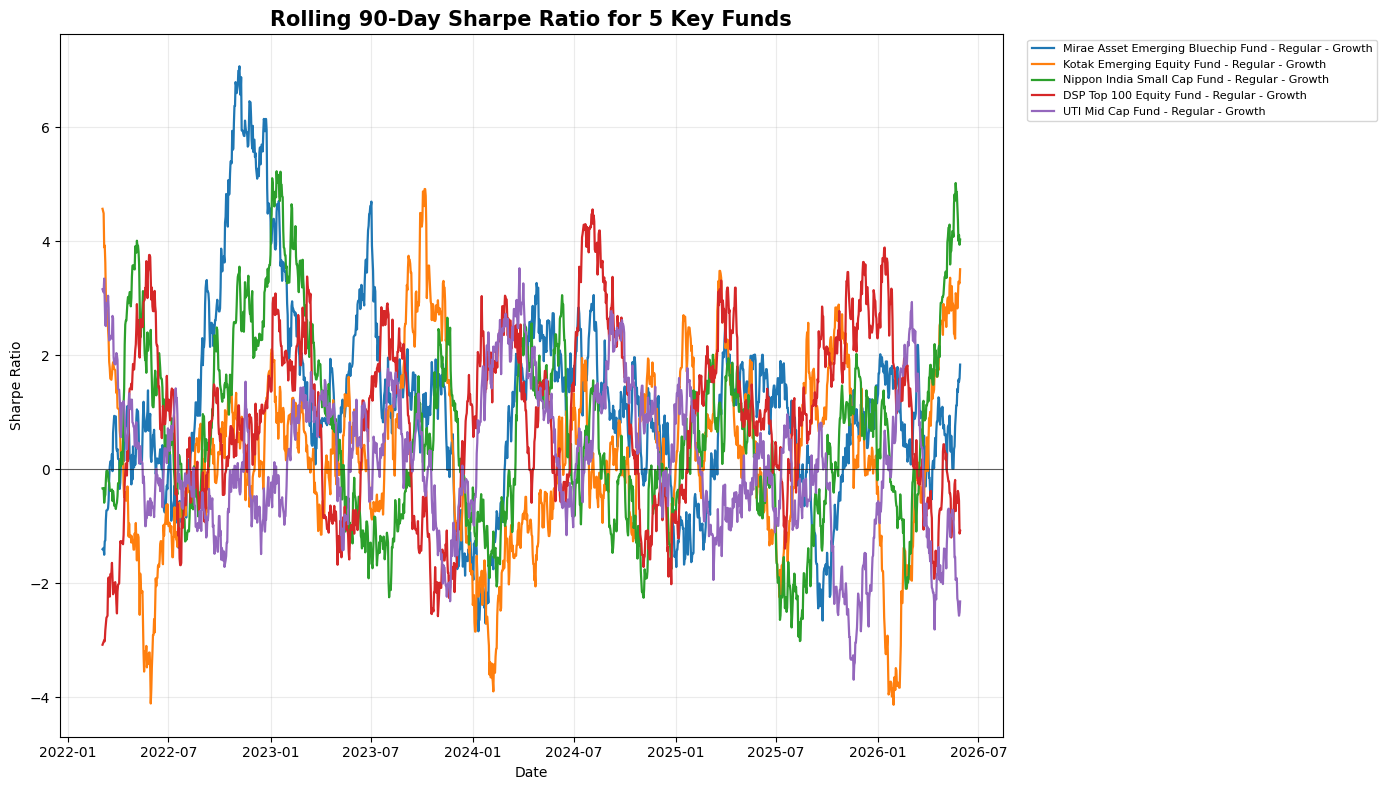

In [3]:
key_funds = perf.sort_values('aum_crore', ascending=False).head(5)[['amfi_code', 'scheme_name', 'aum_crore']].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(14, 8))
for _, row in key_funds.iterrows():
    series = nav.loc[nav['amfi_code'] == row['amfi_code']].set_index('date')['daily_return']
    sharpe = series.rolling(90, min_periods=60).mean() / series.rolling(90, min_periods=60).std() * np.sqrt(252)
    ax.plot(sharpe.index, sharpe.values, label=row['scheme_name'], linewidth=1.6)
ax.set_title('Rolling 90-Day Sharpe Ratio for 5 Key Funds', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
ax.grid(True, alpha=0.25)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
fig.tight_layout()
fig.savefig('rolling_sharpe_chart.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Investor cohort analysis

Investors are grouped by the year of their first transaction. For each cohort we compute the average SIP amount, total invested amount, and the top fund preference.


In [4]:
trx = trx.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
trx['cohort_year'] = trx.groupby('investor_id')['transaction_date'].transform('min').dt.year

cohort_base = trx.groupby('cohort_year').agg(
    investors=('investor_id', 'nunique'),
    total_invested_inr=('amount_inr', 'sum'),
    avg_transaction_amount_inr=('amount_inr', 'mean')
)
cohort_sip = trx.loc[trx['transaction_type'] == 'SIP'].groupby('cohort_year').agg(
    avg_sip_amount_inr=('amount_inr', 'mean'),
    sip_txn_count=('transaction_id', 'size')
)
cohort_pref = (
    trx.groupby(['cohort_year', 'scheme_name'])['amount_inr'].sum()
    .reset_index()
    .sort_values(['cohort_year', 'amount_inr'], ascending=[True, False])
    .drop_duplicates('cohort_year')
    .set_index('cohort_year')
    .rename(columns={'scheme_name': 'top_fund_preference', 'amount_inr': 'top_fund_invested_inr'})
)
cohort_report = cohort_base.join(cohort_sip, how='left').join(cohort_pref[['top_fund_preference', 'top_fund_invested_inr']], how='left').reset_index()
cohort_report


,cohort_year,investors,total_invested_inr,avg_transaction_amount_inr,avg_sip_amount_inr,sip_txn_count,top_fund_preference,top_fund_invested_inr
0,2024,4803,3491125187,107422.541832,10996.885825,19549,UTI Nifty 50 Index Fund - Regular - Growth,100126141
1,2025,197,30455243,109158.577061,13505.209581,167,SBI Small Cap Fund - Direct Plan - Growth,1478507


## 5. SIP continuity analysis

We keep only investors with 6 or more SIP transactions, calculate the average gap between SIP dates, and flag those with an average gap above 35 days as at-risk.


In [5]:
sip = trx.loc[trx['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date']).copy()
sip['gap_days'] = sip.groupby('investor_id')['transaction_date'].diff().dt.days

sip_cont = sip.groupby('investor_id').agg(
    sip_txns=('transaction_id', 'size'),
    avg_gap_days=('gap_days', 'mean'),
    max_gap_days=('gap_days', 'max')
)
sip_cont = sip_cont[sip_cont['sip_txns'] >= 6].copy()
sip_cont['at_risk'] = sip_cont['avg_gap_days'] > 35

continuity_rate = (~sip_cont['at_risk']).mean()
at_risk_count = int(sip_cont['at_risk'].sum())
sip_cont.head(10)


,sip_txns,avg_gap_days,max_gap_days,at_risk
investor_id,,,,
INV000004,6,85.400000,265.0,True
INV000008,6,70.400000,165.0,True
INV000010,6,64.800000,139.0,True
INV000011,7,40.166667,125.0,True
INV000012,8,57.000000,132.0,True
INV000013,7,55.333333,104.0,True
INV000014,7,75.333333,128.0,True
INV000023,8,58.571429,115.0,True
INV000028,6,93.600000,238.0,True


## 6. Simple fund recommender

The recommender maps the requested risk appetite to the closest risk grades and returns the top 3 funds by Sharpe ratio.


In [6]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "MFA"]:
    if (candidate / "recommender.py").exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from recommender import recommend_funds

for risk in ["Low", "Moderate", "High"]:
    print(f"\n=== {risk} ===")
    display(recommend_funds(risk, top_n=3))



=== Low ===


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,return_1yr_pct,aum_crore,expense_ratio_pct
0,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68,7.68,8.89,39116,0.74
1,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18,6.18,4.26,27623,0.60
2,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14,5.14,6.18,38995,0.79



=== Moderate ===


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,return_1yr_pct,aum_crore,expense_ratio_pct
0,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06,14.81,15.12,11361,1.46
1,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06,14.84,10.94,6434,1.55
2,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03,14.41,14.12,41553,0.80



=== High ===


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct,return_1yr_pct,aum_crore,expense_ratio_pct
0,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96,18.23,17.12,47469,1.56
1,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95,18.08,14.02,979,1.36
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High,0.94,23.39,24.56,19259,1.43


## 7. Sector concentration using HHI

Herfindahl-Hirschman Index is computed from normalized sector weights inside each fund. Higher HHI means a more concentrated portfolio.


In [7]:
hold = hold.merge(fund[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='left')
equity_hold = hold.loc[hold['category'] == 'Equity'].copy()

def calc_hhi(group):
    weights = group['weight_pct'].fillna(0)
    total = weights.sum()
    if total <= 0:
        return np.nan
    shares = weights / total
    return float((shares ** 2).sum())

hhi_report = (
    equity_hold.groupby('amfi_code')
    .apply(calc_hhi)
    .rename('hhi')
    .reset_index()
    .merge(fund[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left')
    .sort_values('hhi', ascending=False)
)
hhi_report.head(10)


C:\Users\test\AppData\Local\Temp\ipykernel_21420\415493305.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_hhi)


,amfi_code,hhi,scheme_name,fund_house
11,119092,0.206489,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund
3,101207,0.200741,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund
7,118632,0.168231,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
29,148568,0.167963,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF
21,120505,0.157507,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
22,120506,0.153732,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund
23,120841,0.149650,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF


## 8. Five advanced insights

- Highest 95% VaR: **ABSL Small Cap Fund - Regular - Growth** at **-2.39%** with CVaR **-3.03%**.
- Second-highest downside risk: **Axis Small Cap Fund - Regular - Growth** at **-2.33%** VaR.
- Largest investor cohort is **2024**, investing **INR 3,491,125,187** in total; its top fund is **UTI Nifty 50 Index Fund - Regular - Growth**.
- SIP continuity among investors with 6+ SIPs is **2.2%**; **1332** investors are flagged as at-risk.
- Most concentrated equity fund by HHI is **Axis Bluechip Fund - Regular - Growth** with HHI **0.206**.
